## 1. Problem Statement


Diabetes is a chronic disease affecting millions worldwide.This project builds an Artificial Neural Network (ANN) that predicts whether a patient is likely to have diabetes based on diagnostic measurements. This is a binary classification problem: Class 0 = No diabetes, Class 1 = Diabetes.


## 2. Dataset Description

Pima Indians Diabetes Dataset — 768 rows, 8 input features + 1 target (Outcome):
Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age, Outcome (1=diabetic, 0=non-diabetic).

## 3. Import libraries

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                              accuracy_score, precision_score, recall_score, f1_score)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

print("TensorFlow Version:", tf.__version__)


/Users/lalitabhujel/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TensorFlow Version: 2.20.0


## 4.Import Datasets

In [3]:
df = pd.read_csv("Downloads/diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 5. Data Analysis

In [4]:
print(df.dtypes)
print()
print(df.describe())
print()
df.info()
print()
print("Rows and Columns")
print(df.shape)
print()
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Class distribution (Outcome):")
print(df["Outcome"].value_counts())

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99

## 6. EDA and Visualization

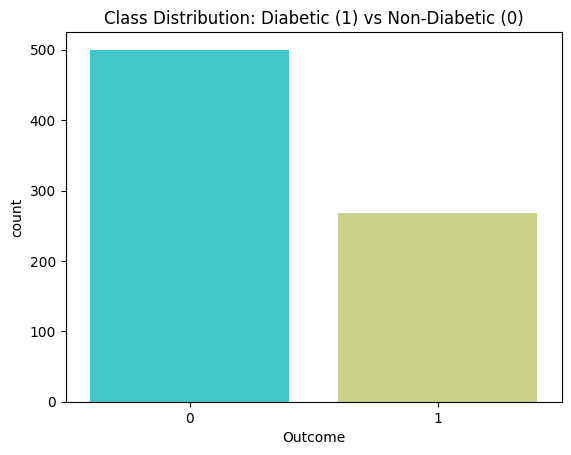

In [5]:
# 1. Count plot of the target variable
sns.countplot(x="Outcome", data=df, palette="rainbow")
plt.title("Class Distribution: Diabetic (1) vs Non-Diabetic (0)")
plt.show()

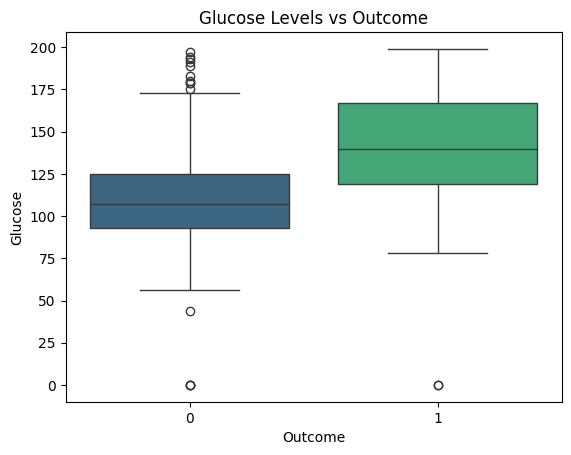

In [6]:
# 2. Boxplot for Glucose grouped by Outcome
sns.boxplot(x="Outcome", y="Glucose", data=df, palette="viridis")
plt.title("Glucose Levels vs Outcome")
plt.show()

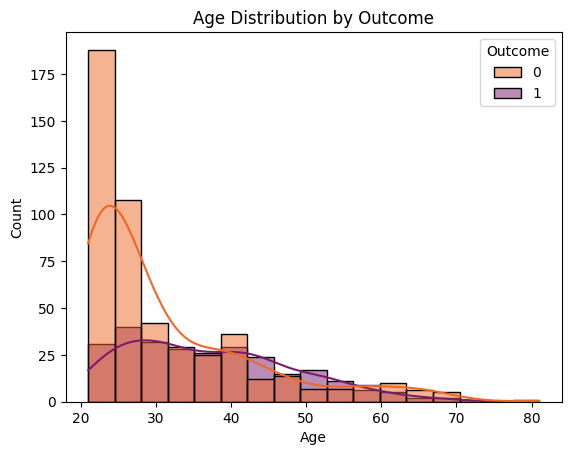

In [7]:
# 3. Age distribution by Outcome
sns.histplot(data=df, x="Age", hue="Outcome", kde=True, palette="inferno_r")
plt.title("Age Distribution by Outcome")
plt.show()

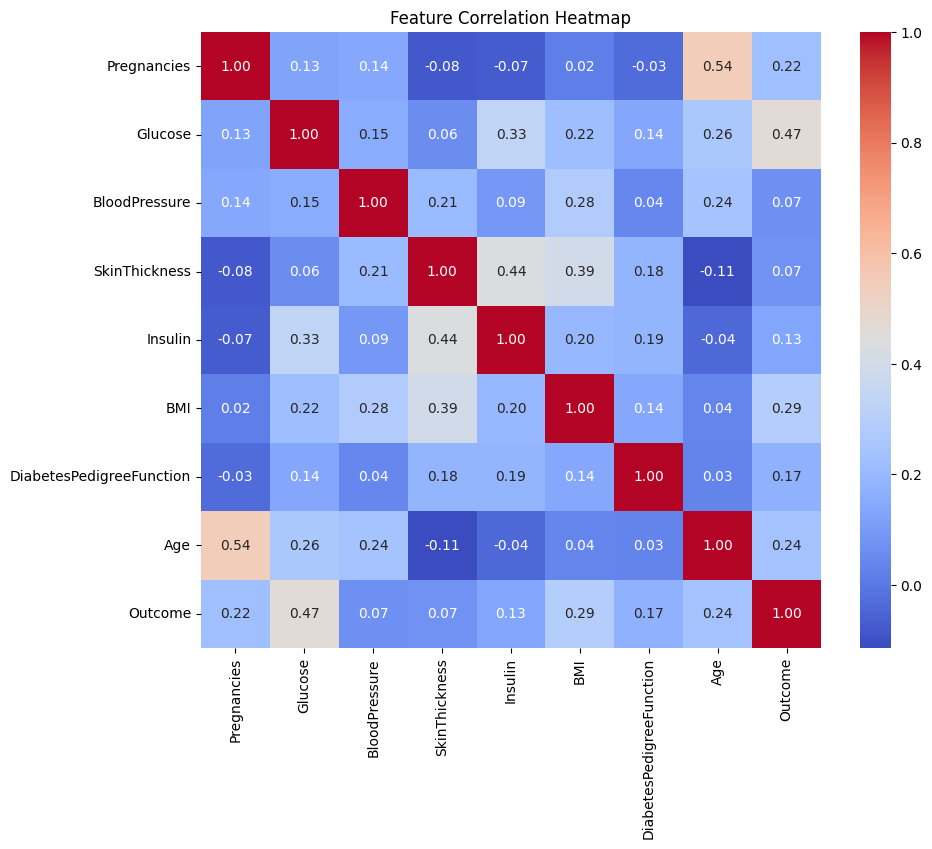

In [8]:
# 4. Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

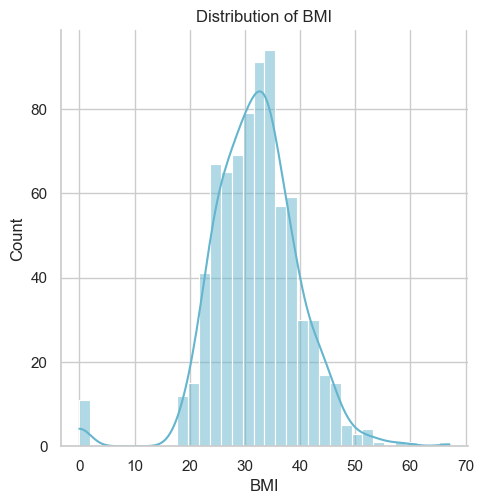

In [9]:
# 5. BMI distribution
sns.set(style="whitegrid")
ax = sns.displot(df["BMI"], kde=True, color="c")
plt.title("Distribution of BMI")
plt.show()

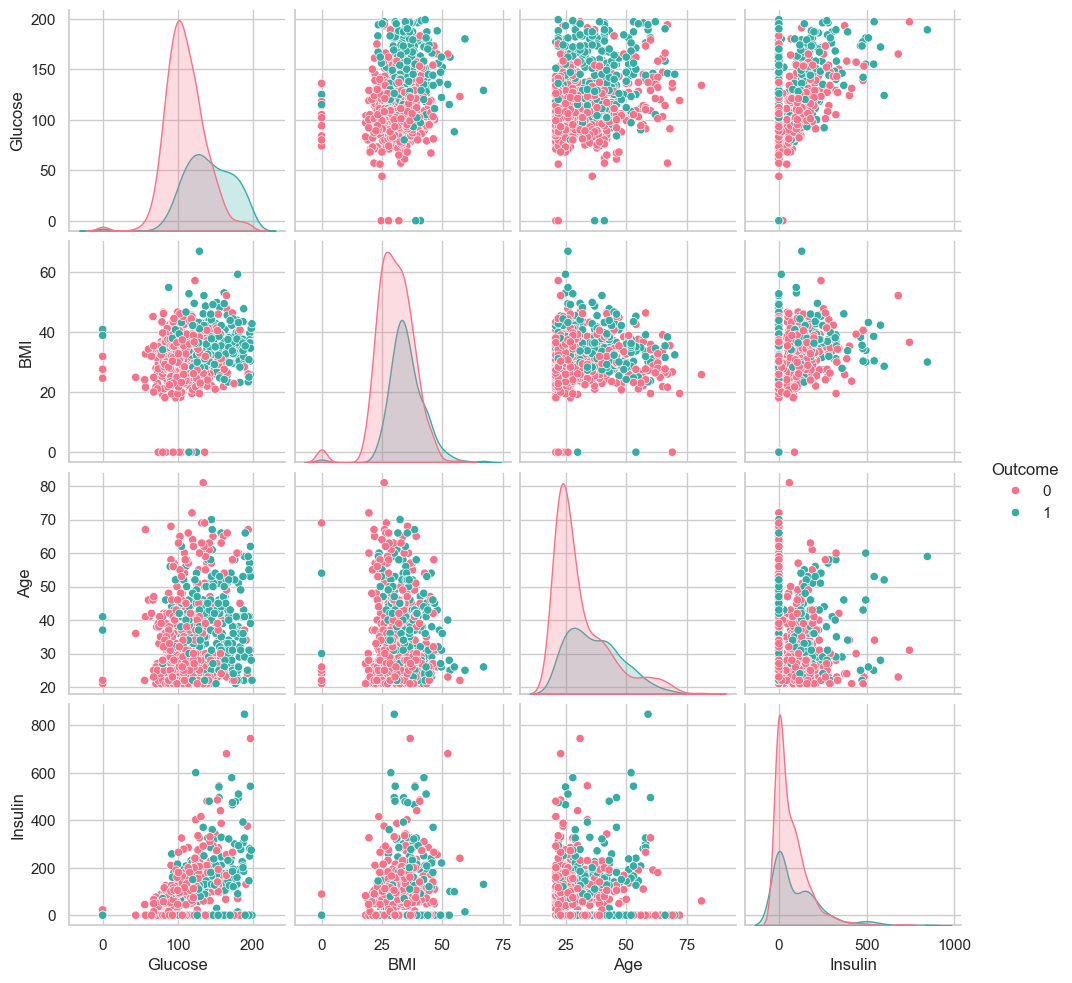

In [10]:
# 6. Pairplot
sns.pairplot(df[["Glucose", "BMI", "Age", "Insulin", "Outcome"]], hue="Outcome", palette="husl")
plt.show()

## 7. Data Preprocessing

In [12]:
cols_with_invalid_zeros = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df[cols_with_invalid_zeros] = df[cols_with_invalid_zeros].replace(0, np.nan)

print("Missing values after marking invalid zeros as NaN:")
print(df[cols_with_invalid_zeros].isnull().sum())

for col in cols_with_invalid_zeros:
    df[col].fillna(df[col].median(), inplace=True)

print()
print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after marking invalid zeros as NaN:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


## 8. Splitting Features and Target

In [13]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (768, 8)
Target shape: (768,)


## 9. Train-Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training Features:", X_train.shape)
print("Training Labels  :", y_train.shape)
print("Testing Features :", X_test.shape)
print("Testing Labels   :", y_test.shape)

y_train.value_counts()

Training Features: (614, 8)
Training Labels  : (614,)
Testing Features : (154, 8)
Testing Labels   : (154,)


Outcome
0    400
1    214
Name: count, dtype: int64

## 10. Feature Scaling

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Sample scaled training data:")
print(X_train_scaled[:5])

Sample scaled training data:
[[-0.85135507 -1.05642747 -0.82674004 -1.91818693 -1.20336073 -0.76947697
   0.31079384 -0.79216928]
 [ 0.35657564  0.14439907  0.47777235 -0.22987447 -1.47019479 -0.41749769
  -0.11643851  0.56103382]
 [-0.5493724  -0.55608308 -1.15286813  1.23332967 -0.55533518  0.3597899
  -0.76486207 -0.70759409]
 [-0.85135507  0.81152492 -1.31593218 -0.00476614 -0.16143729 -0.40283188
   0.26231357 -0.36929331]
 [-1.15333775 -0.88964601 -0.66367599  1.12077551 -0.41556496  1.78237284
  -0.33762972 -0.96131967]]


## 11. ANN Model Building

In [18]:
model = Sequential([
    Dense(16, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(8, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

## 12. Model Training

In [20]:
early_stop = EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7567 - loss: 0.4538 - val_accuracy: 0.7886 - val_loss: 0.4258
Epoch 2/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7916 - loss: 0.4645 - val_accuracy: 0.7886 - val_loss: 0.4236
Epoch 3/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8237 - loss: 0.4091 - val_accuracy: 0.8049 - val_loss: 0.4245
Epoch 4/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 989us/step - accuracy: 0.7909 - loss: 0.4323 - val_accuracy: 0.7886 - val_loss: 0.4251
Epoch 5/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 984us/step - accuracy: 0.7759 - loss: 0.4312 - val_accuracy: 0.7886 - val_loss: 0.4246
Epoch 6/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8038 - loss: 0.4338 - val_accuracy: 0.7967 - val_loss: 0.4249
Epoch 7/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 989us/step - accuracy: 0.7790 - loss: 0.4677 - val_accuracy: 0.7967 - val_loss: 0.4272
Epoch 8/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7689 - loss: 0.4611 - val_accuracy: 0.79

## 13. Training and Validation Graphs

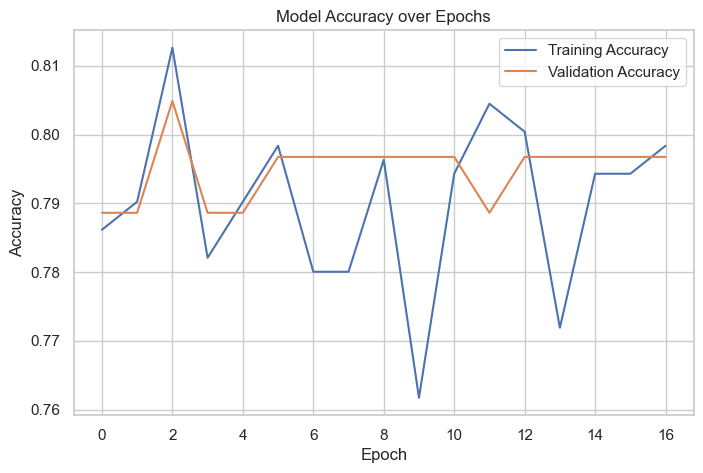

In [22]:
# Accuracy curve
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

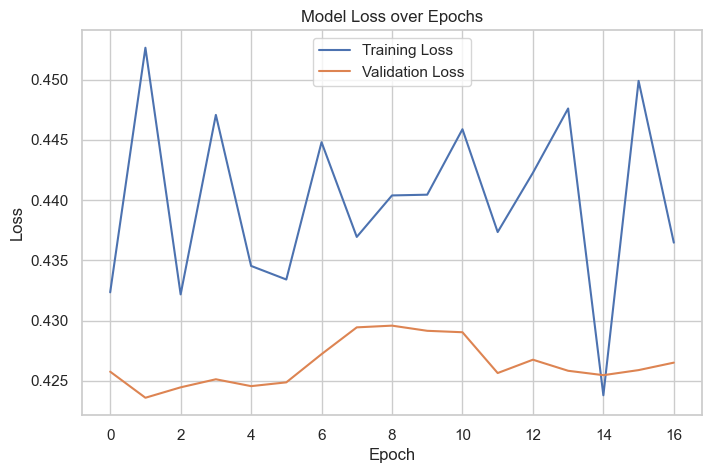

In [25]:
# Loss curve
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 14. Accuracy / Loss Analysis

In [27]:
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

Test Loss     : 0.5005
Test Accuracy : 0.7208


## 15. Predictions on Test Set

In [28]:
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print("Sample predicted probabilities:", y_pred_prob[:5].flatten())
print("Sample predicted classes      :", y_pred[:5])
print("Sample actual classes         :", y_test.values[:5])

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Sample predicted probabilities: [0.6702454  0.08184129 0.4169449  0.31401798 0.00598622]
Sample predicted classes      : [1 0 0 0 0]
Sample actual classes         : [0 0 0 1 0]


## 16. Confusion Matrix

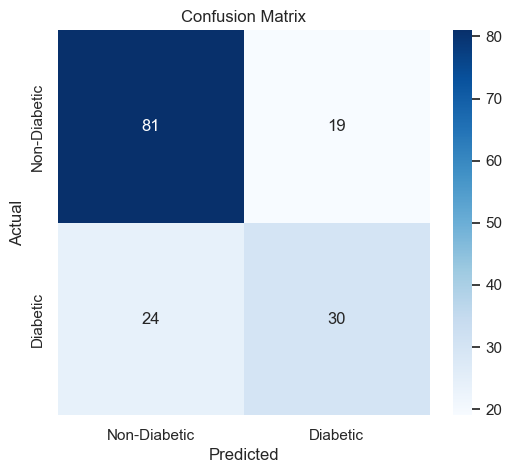

In [30]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-Diabetic", "Diabetic"],
            yticklabels=["Non-Diabetic", "Diabetic"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## 17. Precision, Recall, F1-Score

In [31]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

print()
print("Full Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic", "Diabetic"]))

Accuracy  : 0.7208
Precision : 0.6122
Recall    : 0.5556
F1-Score  : 0.5825

Full Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.77      0.81      0.79       100
    Diabetic       0.61      0.56      0.58        54

    accuracy                           0.72       154
   macro avg       0.69      0.68      0.69       154
weighted avg       0.72      0.72      0.72       154



## 18. Prediction on a New Sample

In [32]:
# [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age]
new_sample = np.array([[2, 150, 80, 30, 100, 33.6, 0.627, 45]])

new_sample_scaled = scaler.transform(new_sample)

prediction_prob = model.predict(new_sample_scaled)
prediction_class = (prediction_prob > 0.5).astype(int)

print(f"Predicted Probability of Diabetes: {prediction_prob[0][0]:.4f}")
if prediction_class[0][0] == 1:
    print("Prediction: The patient is likely DIABETIC.")
else:
    print("Prediction: The patient is likely NON-DIABETIC.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Predicted Probability of Diabetes: 0.5966
Prediction: The patient is likely DIABETIC.


## 19. Conclusion

An ANN was built with TensorFlow to predict diabetes on the Pima Indians dataset. Preprocessing (fixing invalid zero values) and StandardScaler-based feature scaling were essential since ANNs are sensitive to feature magnitude. Training/validation curves show the learning behavior and help detect overfitting. The confusion matrix and precision/recall/F1-score give a fuller picture of performance than accuracy alone, especially with imbalanced classes. The model was tested on a new sample to confirm real-world usability. Future work: hyperparameter tuning, deeper architectures, SMOTE for class imbalance, cross-validation.